In [ ]:
# Install and setup
# torchaudio can cause import errors here, and we do not need it for this notebook.

!pip uninstall -y torchaudio
!pip install -q transformer-lens

Found existing installation: torchaudio 2.11.0+cu128
Uninstalling torchaudio-2.11.0+cu128:
  Successfully uninstalled torchaudio-2.11.0+cu128
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 104.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 118.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
# Load libraries and model

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer, utils

# use GPU if it is available
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HookedTransformer.from_pretrained("gpt2-small", device=device)
model.eval()

torch.set_grad_enabled(False)

print("device:", device)
print("layers:", model.cfg.n_layers)
print("heads:", model.cfg.n_heads)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2-small into HookedTransformer
device: cuda
layers: 12
heads: 12


In [12]:
# Factual prompts
# I kept the prompts in the same format so that the token positions line up nicely.
# The answer has a space at the start because GPT-2 predicts the next token.

facts = [
    ("The capital of France is", " Paris"),
    ("The capital of Italy is", " Rome"),
    ("The capital of Germany is", " Berlin"),
    ("The capital of Spain is", " Madrid"),
    ("The capital of Japan is", " Tokyo"),
    ("The capital of Russia is", " Moscow"),
    ("The capital of China is", " Beijing"),
    ("The capital of Canada is", " Ottawa"),
    ("The capital of Greece is", " Athens"),
    ("The capital of Portugal is", " Lisbon"),
    ("The capital of Norway is", " Oslo"),
    ("The capital of Austria is", " Vienna"),
]

print("number of facts:", len(facts))

number of facts: 12


In [13]:
# Corruption function
# This replaces the subject country with nonsense.


def corrupt(prompt):
    subject = prompt.split("of ")[1].split(" is")[0]
    return prompt.replace(subject, "xyz")


for prompt, answer in facts[:3]:
    print(prompt, "-->", corrupt(prompt))

The capital of France is --> The capital of xyz is
The capital of Italy is --> The capital of xyz is
The capital of Germany is --> The capital of xyz is


In [15]:
# Recovery score
# 0 means no recovery from the corrupted run.
# 1 means the patch fully recovered the clean logit.


def recovery_score(clean, corrupted, patched):
    return (patched - corrupted) / (clean - corrupted + 1e-10)

In [16]:
# Main causal tracing loop using hook_resid_post

n_layers = model.cfg.n_layers
max_len = max(len(model.to_tokens(prompt)[0]) for prompt, _ in facts)

heatmap_sum = np.zeros((n_layers, max_len))
summary_rows = []

for prompt, answer in facts:

    clean_tokens = model.to_tokens(prompt).to(device)
    corrupted_prompt = corrupt(prompt)
    corrupted_tokens = model.to_tokens(corrupted_prompt).to(device)

    answer_token = model.to_single_token(answer)

    # clean and corrupted forward pass
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits = model(corrupted_tokens)

    clean_logit = clean_logits[0, -1, answer_token].item()
    corrupted_logit = corrupted_logits[0, -1, answer_token].item()

    seq_len = min(clean_tokens.shape[1], corrupted_tokens.shape[1])
    heatmap_prompt = np.zeros((n_layers, max_len))

    for layer in range(n_layers):
        hook_name = utils.get_act_name("resid_post", layer)

        for pos in range(seq_len):

            def patch_hook(resid, hook, pos=pos):
                resid[:, pos, :] = clean_cache[hook.name][:, pos, :]
                return resid

            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(hook_name, patch_hook)]
            )

            patched_logit = patched_logits[0, -1, answer_token].item()
            score = recovery_score(clean_logit, corrupted_logit, patched_logit)

            heatmap_prompt[layer, pos] = score

    # Important: add this prompt's heatmap inside the loop
    heatmap_sum += heatmap_prompt

    summary_rows.append({
        "prompt": prompt,
        "answer": answer.strip(),
        "clean_logit": clean_logit,
        "corrupted_logit": corrupted_logit,
        "clean_minus_corrupted": clean_logit - corrupted_logit,
    })

heatmap_avg = heatmap_sum / len(facts)

print("done")
print("heatmap shape:", heatmap_avg.shape)

done
heatmap shape: (12, 6)


In [17]:
# Small sanity check: corruption should usually lower the correct answer logit

summary_df = pd.DataFrame(summary_rows)
summary_df

,prompt,answer,clean_logit,corrupted_logit,clean_minus_corrupted
0,The capital of France is,Paris,11.017086,5.247534,5.769552
1,The capital of Italy is,Rome,12.982533,7.532167,5.450366
2,The capital of Germany is,Berlin,12.102598,6.282037,5.820561
3,The capital of Spain is,Madrid,12.949847,4.719606,8.230241
4,The capital of Japan is,Tokyo,12.204576,8.446421,3.758155
5,The capital of Russia is,Moscow,11.994645,5.844681,6.149964
6,The capital of China is,Beijing,12.048793,8.021140,4.027653
7,The capital of Canada is,Ottawa,10.016402,3.290622,6.725780
8,The capital of Greece is,Athens,13.899974,5.187292,8.712682
9,The capital of Portugal is,Lisbon,11.307472,2.779320,8.528152


In [18]:
print("Average clean - corrupted logit:", summary_df["clean_minus_corrupted"].mean())
print("Number where clean > corrupted:", (summary_df["clean_minus_corrupted"] > 0).sum(), "/", len(summary_df))

Average clean - corrupted logit: 6.246122896671295
Number where clean > corrupted: 12 / 12


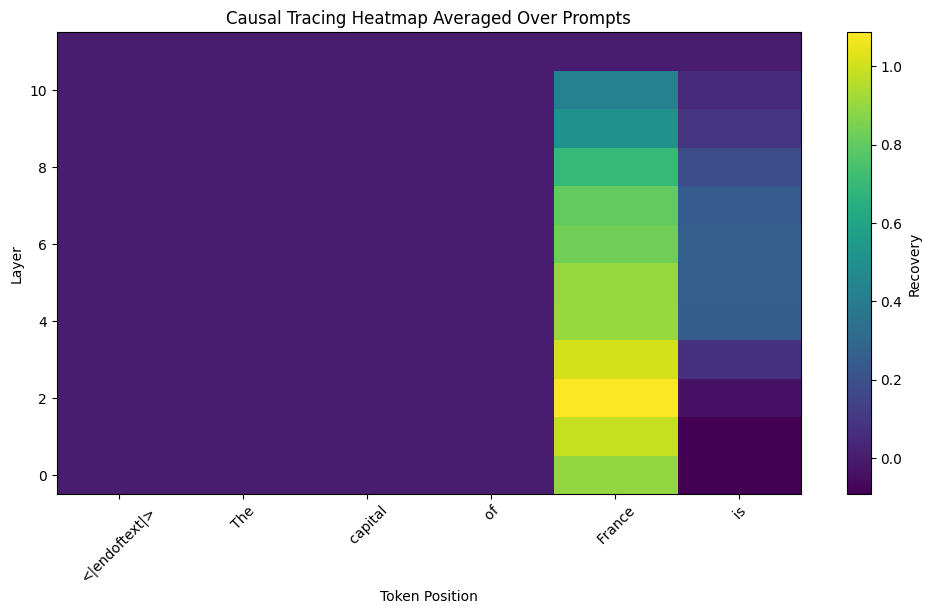

In [19]:
# Plot averaged heatmap

example_tokens = model.to_str_tokens(model.to_tokens(facts[0][0])[0])

plt.figure(figsize=(12, 6))

plt.imshow(
    heatmap_avg,
    aspect="auto",
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="Recovery")
plt.xlabel("Token Position")
plt.ylabel("Layer")
plt.title("Causal Tracing Heatmap Averaged Over Prompts")

plt.xticks(range(len(example_tokens)), example_tokens, rotation=45)

plt.show()

In [20]:
# Show the strongest positions in the averaged heatmap

flat_scores = []

for layer in range(heatmap_avg.shape[0]):
    for pos in range(heatmap_avg.shape[1]):
        flat_scores.append((heatmap_avg[layer, pos], layer, pos))

flat_scores = sorted(flat_scores, reverse=True)

for score, layer, pos in flat_scores[:10]:
    token_name = example_tokens[pos] if pos < len(example_tokens) else str(pos)
    print(f"layer {layer}, position {pos}, token {token_name!r}, recovery {score:.3f}")

layer 2, position 4, token ' France', recovery 1.087
layer 3, position 4, token ' France', recovery 1.013
layer 1, position 4, token ' France', recovery 0.983
layer 4, position 4, token ' France', recovery 0.904
layer 5, position 4, token ' France', recovery 0.899
layer 0, position 4, token ' France', recovery 0.896
layer 6, position 4, token ' France', recovery 0.830
layer 7, position 4, token ' France', recovery 0.802
layer 8, position 4, token ' France', recovery 0.697
layer 9, position 4, token ' France', recovery 0.511


## Answer

In this experiment, restoring the clean residual stream at the subject token recovered a noticeable amount of the correct answer logit. The strongest recovery appeared around the country name token, especially in the earlier to middle layers. This suggests that GPT-2 Small carries important subject related information at those positions, and that this information is causally useful for recalling the capital. It's hard to say if the information is stored in one neuron or layer, but the heatmap gives moderate evidence that the subject token representations in early-to-middle residual stream layers are important for the subject→fact association.